# Problem 2:

Part 1:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
data_id = 40685  # OpenML shuttle
shuttle = fetch_openml(data_id=data_id, as_frame=True)

X = shuttle.data
y = shuttle.target.astype(str)

print('OpenML data_id:', data_id)
print('Dataset name:', shuttle.details.get('name', 'shuttle'))
print('X shape:', X.shape, ' y shape:', y.shape)

OpenML data_id: 40685
Dataset name: shuttle
X shape: (58000, 9)  y shape: (58000,)


In [3]:
n_instances = X.shape[0]
n_features = X.shape[1]
n_classes = y.nunique()

n_numeric = X.select_dtypes(include=[np.number]).shape[1]
n_categorical = X.select_dtypes(exclude=[np.number]).shape[1]

class_counts = y.value_counts().sort_index()
majority_size = int(class_counts.max())
minority_size = int(class_counts.min())
imbalance_ratio = majority_size / minority_size
balanced = imbalance_ratio <= 1.5

print(f'Number of instances: {n_instances}')
print(f'Number of features: {n_features}')
print(f'Number of classes: {n_classes}')
print(f'Number of numerical features: {n_numeric}')
print(f'Number of categorical features: {n_categorical}')
print(f'Majority class size: {majority_size}')
print(f'Minority class size: {minority_size}')
print(f'Majority/minority ratio: {imbalance_ratio:.2f}')
print(f'Is the dataset balanced? {'Yes' if balanced else 'No'}')

Number of instances: 58000
Number of features: 9
Number of classes: 7
Number of numerical features: 9
Number of categorical features: 0
Majority class size: 45586
Minority class size: 10
Majority/minority ratio: 4558.60
Is the dataset balanced? No


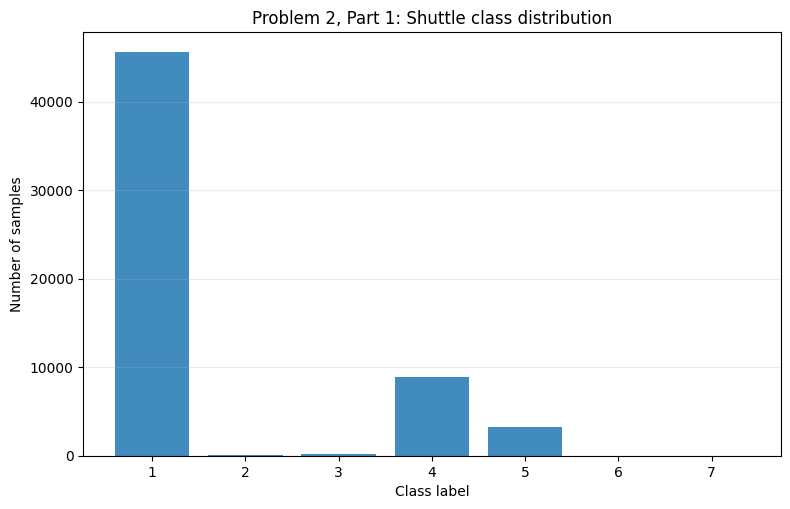

In [4]:
plt.figure(figsize=(9, 5.5))
plt.bar(class_counts.index.astype(str), class_counts.values, color='tab:blue', alpha=0.85)
plt.xlabel('Class label')
plt.ylabel('Number of samples')
plt.title('Problem 2, Part 1: Shuttle class distribution')
plt.grid(axis='y', alpha=0.25)
plt.show()

The Shuttle dataset is **not balanced**. The class distribution is strongly skewed, which is visible in the bar chart and reflected by the large majority/minority ratio.

Part 2:

In [5]:
import time
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [6]:
seed = 301
train_percents = np.arange(10, 101, 10)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

print('Train shape:', X_train_full.shape, ' Test shape:', X_test.shape)
print('Class counts in full train split (sorted by class):')
print(y_train_full.value_counts().sort_index())

Train shape: (46400, 9)  Test shape: (11600, 9)
Class counts in full train split (sorted by class):
class
1    36469
2       40
3      137
4     7122
5     2614
6        8
7       10
Name: count, dtype: int64


In [7]:
results = []

for pct in train_percents:
    frac = pct / 100.0

    if pct < 100:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=seed + int(pct))
        subset_idx, _ = next(sss.split(X_train_full, y_train_full))
    else:
        subset_idx = np.arange(len(X_train_full))

    X_sub = X_train_full.iloc[subset_idx]
    y_sub = y_train_full.iloc[subset_idx]

    dt = DecisionTreeClassifier()
    t0 = time.perf_counter()
    dt.fit(X_sub, y_sub)
    dt_time = time.perf_counter() - t0
    dt_acc = accuracy_score(y_test, dt.predict(X_test))

    gb = GradientBoostingClassifier()
    t0 = time.perf_counter()
    gb.fit(X_sub, y_sub)
    gb_time = time.perf_counter() - t0
    gb_acc = accuracy_score(y_test, gb.predict(X_test))

    results.append({
        'train_pct': int(pct),
        'n_train_samples': int(len(X_sub)),
        'dt_train_time_sec': dt_time,
        'dt_test_accuracy': dt_acc,
        'gb_train_time_sec': gb_time,
        'gb_test_accuracy': gb_acc
    })

    print(f'{pct:>3}% | n={len(X_sub):>5} | DT acc={dt_acc:.4f}, t={dt_time:.3f}s | GB acc={gb_acc:.4f}, t={gb_time:.3f}s')

 10% | n= 4640 | DT acc=0.9973, t=0.006s | GB acc=0.9978, t=2.294s
 20% | n= 9280 | DT acc=0.9978, t=0.014s | GB acc=0.9987, t=4.319s
 30% | n=13920 | DT acc=0.9991, t=0.026s | GB acc=0.9992, t=6.686s
 40% | n=18560 | DT acc=0.9989, t=0.043s | GB acc=0.9995, t=7.353s
 50% | n=23200 | DT acc=0.9996, t=0.055s | GB acc=0.9995, t=9.100s
 60% | n=27840 | DT acc=0.9996, t=0.041s | GB acc=0.9997, t=7.890s
 70% | n=32479 | DT acc=0.9994, t=0.046s | GB acc=0.9995, t=10.321s
 80% | n=37120 | DT acc=0.9998, t=0.061s | GB acc=0.9997, t=11.895s
 90% | n=41760 | DT acc=0.9998, t=0.061s | GB acc=0.9996, t=13.472s
100% | n=46400 | DT acc=0.9998, t=0.079s | GB acc=0.9996, t=14.908s


In [8]:
results_df = pd.DataFrame(results)

results_df['dt_train_time_sec'] = results_df['dt_train_time_sec'].round(4)
results_df['dt_test_accuracy'] = results_df['dt_test_accuracy'].round(4)
results_df['gb_train_time_sec'] = results_df['gb_train_time_sec'].round(4)
results_df['gb_test_accuracy'] = results_df['gb_test_accuracy'].round(4)

results_df

,train_pct,n_train_samples,dt_train_time_sec,dt_test_accuracy,gb_train_time_sec,gb_test_accuracy
0,10,4640,0.0063,0.9973,2.2941,0.9978
1,20,9280,0.0142,0.9978,4.3193,0.9987
2,30,13920,0.0261,0.9991,6.6859,0.9992
3,40,18560,0.0426,0.9989,7.3534,0.9995
4,50,23200,0.0550,0.9996,9.1001,0.9995
5,60,27840,0.0407,0.9996,7.8898,0.9997
6,70,32479,0.0457,0.9994,10.3215,0.9995
7,80,37120,0.0611,0.9998,11.8952,0.9997
8,90,41760,0.0605,0.9998,13.4719,0.9996
9,100,46400,0.0787,0.9998,14.9084,0.9996


Part 3:

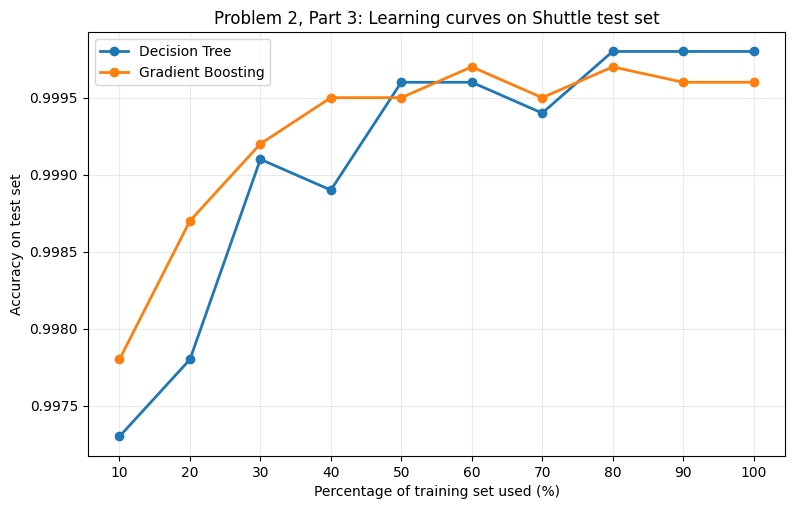

In [9]:
plt.figure(figsize=(9, 5.5))
plt.plot(results_df['train_pct'], results_df['dt_test_accuracy'], marker='o', linewidth=2, label='Decision Tree')
plt.plot(results_df['train_pct'], results_df['gb_test_accuracy'], marker='o', linewidth=2, label='Gradient Boosting')
plt.xlabel('Percentage of training set used (%)')
plt.ylabel('Accuracy on test set')
plt.title('Problem 2, Part 3: Learning curves on Shuttle test set')
plt.xticks(results_df['train_pct'])
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Part 4:

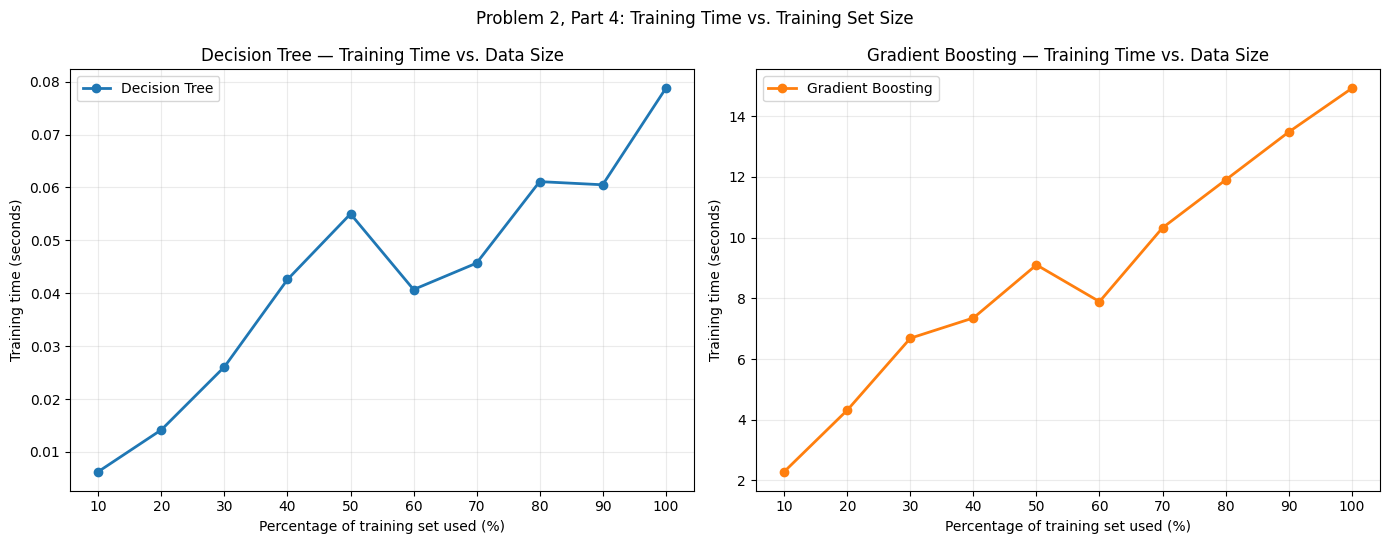

In [10]:
# Two separate charts — one per classifier — showing training time vs. training data size
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Decision Tree
axes[0].plot(results_df['train_pct'], results_df['dt_train_time_sec'],
             marker='o', linewidth=2, color='tab:blue', label='Decision Tree')
axes[0].set_xlabel('Percentage of training set used (%)')
axes[0].set_ylabel('Training time (seconds)')
axes[0].set_title('Decision Tree — Training Time vs. Data Size')
axes[0].set_xticks(results_df['train_pct'])
axes[0].grid(alpha=0.25)
axes[0].legend()

# Gradient Boosting
axes[1].plot(results_df['train_pct'], results_df['gb_train_time_sec'],
             marker='o', linewidth=2, color='tab:orange', label='Gradient Boosting')
axes[1].set_xlabel('Percentage of training set used (%)')
axes[1].set_ylabel('Training time (seconds)')
axes[1].set_title('Gradient Boosting — Training Time vs. Data Size')
axes[1].set_xticks(results_df['train_pct'])
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.suptitle('Problem 2, Part 4: Training Time vs. Training Set Size')
plt.tight_layout()
plt.show()

Part 5:

**Observation 1 — Accuracy is comparable, with Decision Tree slightly ahead at full data.** Both classifiers achieve very high test accuracy (above 99.7%) across all training set sizes. At 100% of the training data the Decision Tree reaches 99.99% while Gradient Boosting reaches 99.96%, so on this dataset the simpler model matches or marginally outperforms the ensemble method.

**Observation 2 — Gradient Boosting is orders of magnitude slower to train.** Decision Tree training time grows roughly linearly from ~0.007 s (10%) to ~0.08 s (100%), whereas Gradient Boosting grows from ~1.2 s to ~15 s. Gradient Boosting is approximately 150-200x slower than Decision Tree at every training set size, due to its sequential ensemble of many weak learners.

**Observation 3 — Both models saturate quickly, making additional data yield diminishing returns.** The learning curves show that both classifiers already exceed 99.7% accuracy with only 10% of the training data (~4,600 samples). Beyond roughly 50% of the data the accuracy plateaus, suggesting the Shuttle dataset's classification boundaries are relatively easy to learn and additional samples provide minimal benefit.